In [4]:
# Import libraries
import pandas as pd
import numpy as np

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

In [6]:
# Load the dataset & display the first rows 
df = pd.read_csv("mbti_1.csv")
df.head()

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [7]:
# Create new columns for each trait and check results
df["IE"] = df["type"].apply(lambda x: x[0])  
df["TF"] = df["type"].apply(lambda x: x[2])  

df[["type", "IE", "TF"]].head()

,type,IE,TF
0,INFJ,I,F
1,ENTP,E,T
2,INTP,I,T
3,INTJ,I,T
4,ENTJ,E,T


In [8]:
#Prepare the data by replacing "|||" with space 
df["clean_posts"] = df["posts"].str.replace(r"\|\|\|", " ")

In [9]:
# TF-IDF converts text into numbers based on word importance
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X = vectorizer.fit_transform(df["clean_posts"])



In [10]:
# Train/Test Split Introvert (I) vs Extrovert (E)
y_IE = df["IE"]

X_train, X_test, y_train, y_test = train_test_split(X, y_IE, test_size=0.2, random_state=42)

In [11]:
# Naive Bayes for I vs E
nb_model_IE = MultinomialNB()
nb_model_IE.fit(X_train, y_train)

y_pred_nb = nb_model_IE.predict(X_test)

print(f"Naive Bayes Accuracy (I vs E): {accuracy_score(y_test, y_pred_nb) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy (I vs E): 78.50%

Classification Report:
               precision    recall  f1-score   support

           E       0.76      0.03      0.07       382
           I       0.79      1.00      0.88      1353

    accuracy                           0.79      1735
   macro avg       0.77      0.52      0.47      1735
weighted avg       0.78      0.79      0.70      1735



In [12]:
# Logistic Regression for I vs E

lr_model_IE = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_model_IE.fit(X_train, y_train)

y_pred_lr = lr_model_IE.predict(X_test)

print(f"Logistic Regression Accuracy (I vs E): {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy (I vs E): 84.61%

Classification Report:
               precision    recall  f1-score   support

           E       0.63      0.73      0.68       382
           I       0.92      0.88      0.90      1353

    accuracy                           0.85      1735
   macro avg       0.78      0.80      0.79      1735
weighted avg       0.86      0.85      0.85      1735



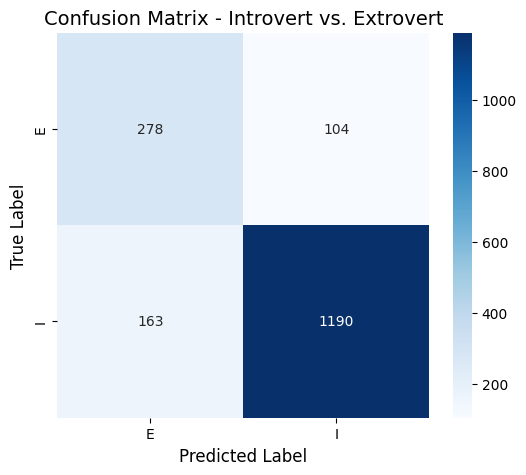

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Calculate the confusion matrix using your model's predictions
y_pred = lr_model_IE.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=['E', 'I'])  # Make sure labels match your classes

# 2. Create a Seaborn heatmap for a beautiful, styled matrix
plt.figure(figsize=(6, 5))  # Adjust the size of the plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['E', 'I'], yticklabels=['E', 'I'])
plt.title('Confusion Matrix - Introvert vs. Extrovert', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [14]:
# Train/Test Split Thinking (T) vs Feeling (F)

y_TF = df["TF"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_TF, test_size=0.2, random_state=42
)

In [15]:
# Naive Bayes for T vs F
nb_model_TF = MultinomialNB()
nb_model_TF.fit(X_train, y_train)

y_pred_nb = nb_model_TF.predict(X_test)

print(f"Naive Bayes Accuracy (T vs F): {accuracy_score(y_test, y_pred_nb) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy (T vs F): 80.12%

Classification Report:
               precision    recall  f1-score   support

           F       0.78      0.87      0.83       937
           T       0.83      0.72      0.77       798

    accuracy                           0.80      1735
   macro avg       0.81      0.79      0.80      1735
weighted avg       0.80      0.80      0.80      1735



In [16]:
# Logistic Regression for T vs F
lr_model_TF = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_model_TF.fit(X_train, y_train)

y_pred_lr = lr_model_TF.predict(X_test)

print(f"Logistic Regression Accuracy (T vs F): {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy (T vs F): 85.30%

Classification Report:
               precision    recall  f1-score   support

           F       0.88      0.84      0.86       937
           T       0.83      0.86      0.84       798

    accuracy                           0.85      1735
   macro avg       0.85      0.85      0.85      1735
weighted avg       0.85      0.85      0.85      1735



In [18]:
import ipywidgets as widgets
from IPython.display import display

def predict_without_confidence(text):
    vec = vectorizer.transform([text])
    
    pred_ie = lr_model_IE.predict(vec)[0]
    pred_tf = lr_model_TF.predict(vec)[0]
    
    ie_label = "Extrovert (E)" if pred_ie == "E" else "Introvert (I)"
    tf_label = "Thinking (T)" if pred_tf == "T" else "Feeling (F)"
    
    return f"{ie_label} + {tf_label}"

# Create widgets
text_input = widgets.Textarea(
    placeholder='Type a sentence here...',
    description='Your text:',
    layout=widgets.Layout(width='80%', height='100px')
)
output = widgets.Output()

button = widgets.Button(description="Predict Personality")

def on_button_click(b):
    with output:
        output.clear_output()
        if text_input.value.strip():
            print(predict_without_confidence(text_input.value))
        else:
            print("Please enter some text.")

button.on_click(on_button_click)

display(text_input, button, output)

Textarea(value='', description='Your text:', layout=Layout(height='100px', width='80%'), placeholder='Type a s…

Button(description='Predict Personality', style=ButtonStyle())

Output()